# EA3 — Dashboard
**Proyecto:** Incidentes viales – Medellín  
**Objetivo:** Generar **gráficos descriptivos** y guardarlos en `docs/graficos/` leyendo **solo** `data/dataset_enriquecido.csv`.  
**Ventaja:** No dependemos de SQLite ni Git LFS para esta entrega.

**Gráficos:**  
1) Barras por *clase_accidente*  
2) Barras por *gravedad*  
3) Top 10 *comuna*  
4) Histograma por *hora_num*  
5) Serie mensual (*anio_mes*)


## 1) Carga del CSV (enriquecido)
Coloca el archivo en `data/dataset_enriquecido.csv`. Si no existe, el cuaderno falla con un mensaje claro.


In [14]:
import pandas as pd, numpy as np, sqlite3
from pathlib import Path

USE_ONLY_CSV = False
REPAIR_FROM_DB = True

def find_project_root(max_up=5):
    cwd = Path.cwd()
    if cwd.name.lower() in {"notebooks", "dashboard"}:
        cwd = cwd.parent
    candidates = [cwd] + list(cwd.parents[:max_up])
    for d in candidates:
        if (d / "data").exists():
            return d
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
DB_PATH  = PROJECT_ROOT / "db" / "proyecto.db"
CSV_PATH = DATA_DIR / "dataset_enriquecido.csv"

# 2) Cargar según preferencia
def load_from_csv(path: Path) -> pd.DataFrame:
    assert path.exists(), f"No encontré {path}. Copia/crea data/dataset_enriquecido.csv"
    return pd.read_csv(path, low_memory=False)

def table_exists(con, name:str)->bool:
    q = "SELECT name FROM sqlite_master WHERE type='table' AND name=?;"
    return not pd.read_sql(q, con, params=(name,)).empty

def export_csv_from_db(csv_out: Path):
    con = sqlite3.connect(str(DB_PATH))
    try:
        if table_exists(con, "incidentes_enriquecido"):
            df_ = pd.read_sql("SELECT * FROM incidentes_enriquecido;", con)
        elif table_exists(con, "incidentes"):
            df_ = pd.read_sql("SELECT * FROM incidentes;", con)
        else:
            raise RuntimeError("La DB existe pero no encuentro tablas esperadas: incidentes_enriquecido / incidentes")
    finally:
        con.close()
    csv_out.parent.mkdir(parents=True, exist_ok=True)
    df_.to_csv(csv_out, index=False, encoding="utf-8")
    print("CSV reconstruido desde SQLite →", csv_out)
    return df_

if USE_ONLY_CSV:
    df, SRC = load_from_csv(CSV_PATH), str(CSV_PATH)
else:
    if CSV_PATH.exists():
        df, SRC = load_from_csv(CSV_PATH), str(CSV_PATH)
    else:
        if REPAIR_FROM_DB and DB_PATH.exists():
            df, SRC = export_csv_from_db(CSV_PATH), "sqlite→csv"
        else:
            # Último recurso: falla guiado
            raise FileNotFoundError(f"No encontré {CSV_PATH}. "
                                    f"Si usas Git LFS para la DB ejecuta: 'git lfs pull' y vuelve a correr (o pon USE_ONLY_CSV=True).")

## 2) Normalización mínima
- Estandariza nombres a minúsculas.
- Renombra columnas comunes del diccionario (`CLASE_ACCIDENTE`, `GRAVEDAD_ACCIDENTE`, `COMUNA`, `FECHA_ACCIDENTES`, etc.).
- Deriva: `anio`, `mes`, `dia`, `anio_mes`, `hora_num`, `franja_horaria` si faltan.


In [15]:
# 2.1) Nombres en minúsculas
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# 2.2) Renombres desde diccionario oficial (si vinieran en mayúsculas)
rename_map = {
    'clase_accidente': 'clase_accidente',
    'gravedad_accidente': 'gravedad',
    'comuna': 'comuna',
    'numcomuna': 'numcomuna',
    'fecha_accidentes': 'fecha_accidentes',
    'año': 'anio',
    'mes': 'mes'
}
for k, v in list(rename_map.items()):
    if k in df.columns and v not in df.columns:
        df.rename(columns={k: v}, inplace=True)

# 2.3) Derivar fecha si existe 'fecha_accidentes'
if 'fecha_accidentes' in df.columns:
    dt = pd.to_datetime(df['fecha_accidentes'], errors='coerce')
    df['anio'] = df.get('anio', dt.dt.year)
    df['mes']  = df.get('mes', dt.dt.month)
    df['dia']  = dt.dt.day
    df['hora_num'] = dt.dt.hour
    df['anio_mes'] = dt.dt.to_period('M').astype(str)
else:
    # Si no hay fecha, intenta a partir de 'anio' y 'mes'
    if 'anio' in df.columns and 'mes' in df.columns:
        try:
            df['anio'] = pd.to_numeric(df['anio'], errors='coerce').astype('Int64')
            df['mes']  = pd.to_numeric(df['mes'], errors='coerce').astype('Int64')
            df['anio_mes'] = df.apply(lambda r: f"{int(r['anio']):04d}-{int(r['mes']):02d}" if pd.notna(r['anio']) and pd.notna(r['mes']) else np.nan, axis=1)
        except Exception:
            df['anio_mes'] = np.nan

# 2.4) Franja horaria (simple)
def bucket_hora(h):
    try:
        h = int(h)
    except Exception:
        return 'Sin hora'
    if   0 <= h < 6:  return 'Madrugada'
    elif 6 <= h < 12: return 'Mañana'
    elif 12 <= h < 18:return 'Tarde'
    elif 18 <= h < 24:return 'Noche'
    else:             return 'Sin hora'

if 'hora_num' not in df.columns:
    df['hora_num'] = np.nan
df['franja_horaria'] = df['hora_num'].apply(bucket_hora)

# 2.5) Aliases finales por si vienen con otro nombre
if 'clase_accidente' not in df.columns:
    for alt in ['clase','tipo_accidente']:
        if alt in df.columns:
            df.rename(columns={alt: 'clase_accidente'}, inplace=True)
            break
if 'gravedad' not in df.columns:
    for alt in ['gravedad_accidente']:
        if alt in df.columns:
            df.rename(columns={alt: 'gravedad'}, inplace=True)
            break

for c in ['anio','mes','dia','hora_num']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

cols_preview = ['anio','mes','dia','anio_mes','hora_num','franja_horaria','clase_accidente','gravedad','comuna']
print('Preview columnas clave (si faltan verás NaN):')
df[ [c for c in cols_preview if c in df.columns] ].head(5)

Preview columnas clave (si faltan verás NaN):


,anio,mes,dia,anio_mes,hora_num,franja_horaria,clase_accidente,gravedad,comuna
0,2015,10,21,2015-10,10,Mañana,Caida Ocupante,Con heridos,La Candelaria
1,2015,11,5,2015-11,8,Mañana,Choque,Solo daños,La Candelaria
2,2015,10,21,2015-10,12,Tarde,Otro,Con heridos,Santa Cruz
3,2015,10,21,2015-10,17,Tarde,Atropello,Con heridos,Popular
4,2015,11,3,2015-11,11,Mañana,Choque,Solo daños,Guayabal


## 3) Gráficos con Matplotlib (sin dependencias extra)
Se guardan en `docs/graficos/`.


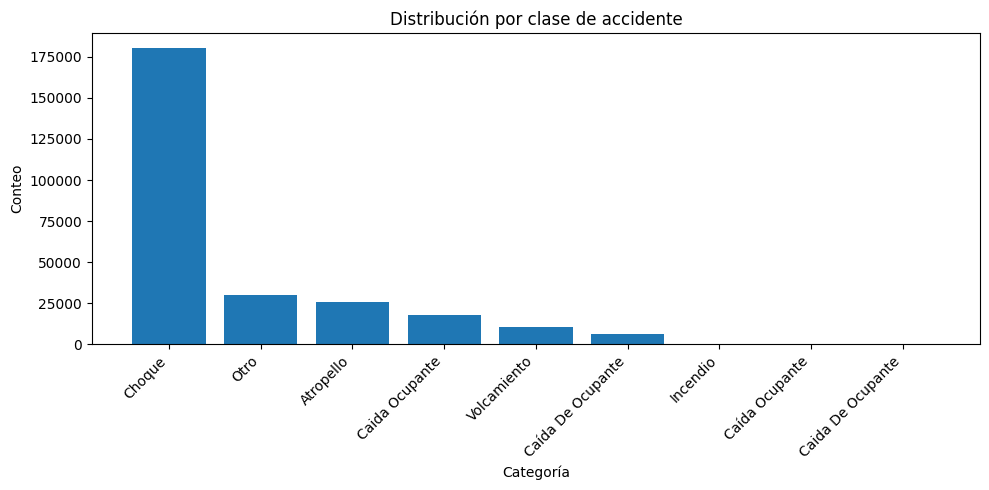

Guardado → c:\Dev\proyecto_integrado_ea1\dashboard\docs\graficos\01_clase_accidente.png


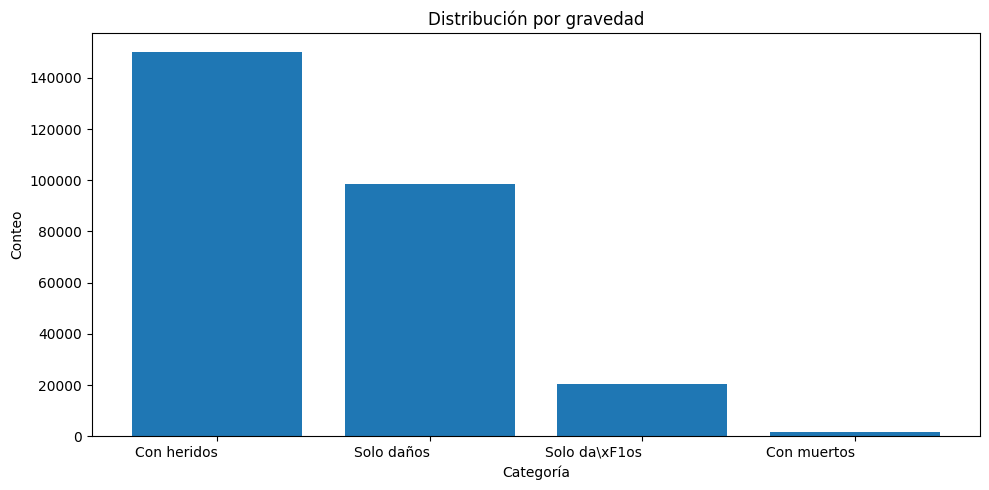

Guardado → c:\Dev\proyecto_integrado_ea1\dashboard\docs\graficos\02_gravedad.png


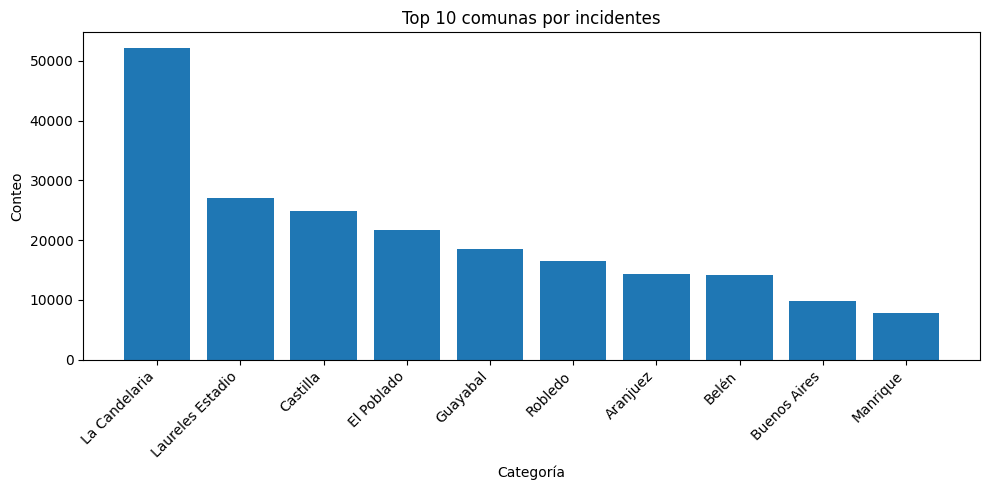

Guardado → c:\Dev\proyecto_integrado_ea1\dashboard\docs\graficos\03_top_comunas.png


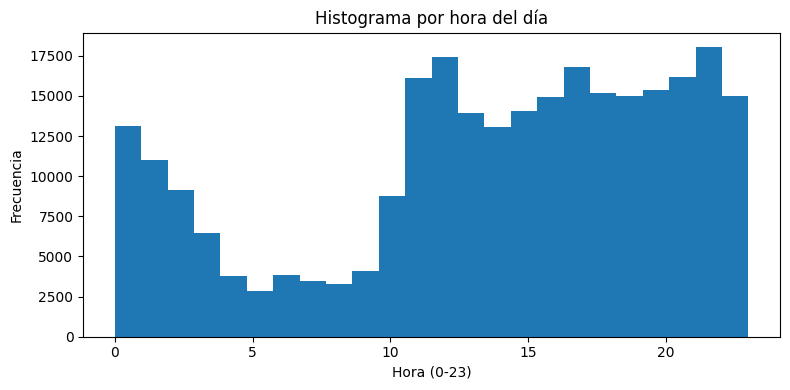

Guardado → c:\Dev\proyecto_integrado_ea1\dashboard\docs\graficos\04_hist_hora.png


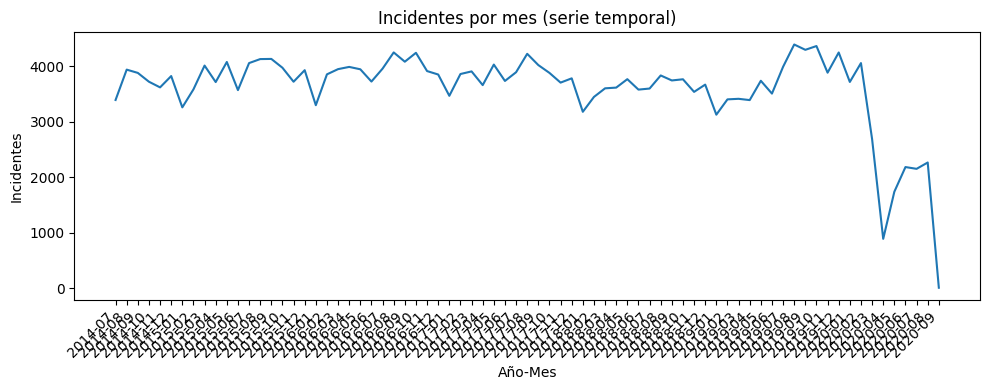

Guardado → c:\Dev\proyecto_integrado_ea1\dashboard\docs\graficos\05_serie_mensual.png


In [16]:
import matplotlib.pyplot as plt
import os
outdir = ROOT / 'docs' / 'graficos'
outdir.mkdir(parents=True, exist_ok=True)

def save_bar(series, title, fname, top=None, rotate=45):
    vc = series.value_counts().dropna()
    if top: vc = vc.head(top)
    plt.figure(figsize=(10,5))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel('Categoría'); plt.ylabel('Conteo')
    plt.xticks(rotation=rotate, ha='right')
    plt.tight_layout()
    path = outdir / fname
    plt.savefig(path, dpi=150)
    plt.show()
    print('Guardado →', path)

# 3.1) Clase de accidente
if 'clase_accidente' in df.columns:
    save_bar(df['clase_accidente'], 'Distribución por clase de accidente', '01_clase_accidente.png')
else:
    print('No existe columna clase_accidente')

# 3.2) Gravedad
if 'gravedad' in df.columns:
    save_bar(df['gravedad'], 'Distribución por gravedad', '02_gravedad.png', rotate=0)
else:
    print('No existe columna gravedad')

# 3.3) Top 10 comunas
if 'comuna' in df.columns:
    save_bar(df['comuna'], 'Top 10 comunas por incidentes', '03_top_comunas.png', top=10)
else:
    print('No existe columna comuna')

# 3.4) Histograma por hora
if 'hora_num' in df.columns and df['hora_num'].notna().any():
    hh = df['hora_num'].dropna().astype(int)
    plt.figure(figsize=(8,4))
    plt.hist(hh, bins=24)
    plt.title('Histograma por hora del día')
    plt.xlabel('Hora (0-23)'); plt.ylabel('Frecuencia')
    plt.tight_layout()
    path = outdir / '04_hist_hora.png'
    plt.savefig(path, dpi=150)
    plt.show()
    print('Guardado →', path)
else:
    print('No hay hora_num válida para histograma')

# 3.5) Serie mensual
if 'anio_mes' in df.columns and df['anio_mes'].notna().any():
    ts = df.groupby('anio_mes').size().reset_index(name='total').sort_values('anio_mes')
    plt.figure(figsize=(10,4))
    plt.plot(ts['anio_mes'], ts['total'])
    plt.title('Incidentes por mes (serie temporal)')
    plt.xlabel('Año-Mes'); plt.ylabel('Incidentes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = outdir / '05_serie_mensual.png'
    plt.savefig(path, dpi=150)
    plt.show()
    print('Guardado →', path)
else:
    print('No hay anio_mes para la serie temporal')
